In [4]:
# -----------------------------
# Import libraries
# -----------------------------

from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from xgboost import XGBRegressor
#from tqdm import tqdm
import time
from scipy.stats import uniform
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [5]:
pnw = pd.read_csv(
    "../data/raw/NCASIpollen_raw.csv",
    encoding="latin1",
    low_memory=False
)

# Columns you expect to exist
cols = ["SampleID", "Stand"]

# Keep only columns that are actually present in the CSV
cols = [c for c in cols if c in pnw.columns]

# Collect RBCL columns
rbcl_cols = [c for c in pnw.columns if c.startswith("RBCL:")]

# Subset the dataframe (make a copy to avoid warnings)
pnw_sub = pnw[cols + rbcl_cols].copy()

# Create UniqueID and Site safely
if "SampleID" in pnw_sub.columns:
    pnw_sub["UniqueID"] = pnw_sub["SampleID"]

if "Stand" in pnw_sub.columns:
    pnw_sub["Site"] = pnw_sub["Stand"]

# Final column order
new_cols = [c for c in ["UniqueID", "Site"] if c in pnw_sub.columns]

pnw_final = pnw_sub[new_cols + rbcl_cols]

pnw_final["Project"] = "PNW"

pnw_final.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_24356\856468580.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pnw_final["Project"] = "PNW"


,UniqueID,Site,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTAGCAGCATTTCGAGTAAGTCCTCAACCTGGAGTTCCCCCAGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAGGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACCGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,...,RBCL:CTCCTGACTATGAAACCAAAGATATTGCTATCTTGGCAGCATTCTGAGTAACTCCTCAATCTGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCCGAATCTTGGACTGGTACATGAACAACTGTGTGAATCGATAGACATATTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCCGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAGTTGTGTGGACCGATGGGCTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTGGCAGCAATCCGAGTAACTCCTCAACCAGGAGTTCCACCTAAAGAAACAGGGGCCGTGGTAGCGGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTAGCAGCAATCCGAGTAACTCCTCAATCAGGAGTTCCACCTAAAGAAGCAGGGGCCCCGGTAGCGGCGGAATCTTCTCCTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCCGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCGACTGGTACATGGACAGTTGTGTGGACCGATGGGCTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGCGTTCCACCGGAGGAAGCAGGAGCAGCGGTAGCTGCGGAATCTTCTACTGGTACCTGGACAACTGTTTGGACAGATGGACTGACCAGTCTTGATCGTTATAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTAGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGTGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGAAGCAGGGGCCGCAGTAGCCGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATTCTGATATCTTGGCAGCAATCCGAGTAACTCCTCAACCAGGAGTTCCACCTAAAGAAGCAGGGGCCCCGGTAGCGGCGGGATCTTCTACTGGTACATGGACAACTGTGTGGACTGATGGACTTACTAGCCTTGAACGTTACAAAGGGCGCTGCTAC,Project
0,NCASI-S63152,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
1,NCASI-S63154,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
2,NCASI-S63138,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
3,NCASI-S63135,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW
4,NCASI-S63145,1:BigLake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PNW


In [6]:
## import data

ca = pd.read_csv("../data/raw/FFARpollen_raw.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in ca.columns if c.startswith("RBCL:")]

ca_sub = ca[cols + rbcl_cols]

ca_sub["Project"] = "CA"
ca_sub.head()


C:\Users\rah10\AppData\Local\Temp\ipykernel_24356\567351007.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_sub["Project"] = "CA"


,UniqueID,Site,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCCGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTACGAAACCAAAGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCAGGGGCAGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTATGGACTGACGGGCTTACTAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTAAAGAAGCGGGGGCCACGATAGCTGCCGAATCTTCTACTGGTACATGGACCACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGAGACTGATATCTTAGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAGCGGGGGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGTGCAGCGGTAGCTGCCGAATCTTCCACTGGGACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCAGGAGTTCCGCCTGAAGAAGCAGGTGCCGCGGTAGCCGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGTTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,...,RBCL:CTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCACCTGAAGAAACGGGGGCCGCGGCAGCTGCCGAATCTTCTACTGGTACATGGGCCACTTTGTGGACCGATGGACTTACCAGCCTCGATCCTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTTATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCACCTGAAGAAGCAGGGGCTGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTATCTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCGGGAGTTCCACCTGAGGAAGCAGGGGCAGCTGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCACCTGAAGAAGCAGAGGCTGCGGTAGCTGCTGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATATGAAACCAAAGGCTAAGTTAAAATTTGGCGTTGTTGCGAGTAGAGTCCCCTTTTATTGTGTCAGTACCGTTATTTGCATCACAAGTTAGGCCCTTAGCGTTTGGAAGAGAATACAAATTATACGAACCCTTCGATTTCTCCAAGTCCGTTCGATTTAAAACTGGAGAGGGTGTAGCCGACGACTGGGAAGGCTTCGCTGGTAGCGGAGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAAGTCCGAAACCTGGAGTTCCGGCTGAAGAAGCAGGTGCAGCGGTAGCTGCCGAATCTTCCACTGGGACATGGACAACTGTGTGGACCGATGGACTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGACTATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAACCTTGATCGTTACAAAGGGCGCTGCTAC,RBCL:CTCCTGAATACGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAACCTTGATCGTTACAAAGGGCGCTGCTAC,Project
0,SF262,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
1,SF263,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
2,SF261,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
3,SF266,Turk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA
4,SF267,Turk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA


In [7]:
## import data

si = pd.read_csv("../data/raw/SIpollen_raw.csv", encoding="latin1", low_memory=False)

cols = ["UniqueID", "Site"]

rbcl_cols = [c for c in si.columns if c.startswith("RBCL:")]

si_sub = si[cols + rbcl_cols]

si_sub["Project"] = "SI"
si_sub.shape

C:\Users\rah10\AppData\Local\Temp\ipykernel_24356\1279891967.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si_sub["Project"] = "SI"


(19031, 243)

In [8]:
# This will display all columns without truncation.
pd.set_option('display.max_columns', None)

## merging all dataframes for projects
df_merged = (
    pnw_final.merge(si_sub, on=["UniqueID", "Site", "Project"], how="outer")
       .merge(ca_sub, on=["UniqueID", "Site", "Project"], how="outer")
)


In [ ]:
import pandas as pd

## combining columns from different datasets with the same id

# Find columns with "_x" suffix
for col in df_merged.columns:
    if col.endswith("_x"):
        base = col[:-2]  # remove "_x"
        col_y = base + "_y"
        
        if col_y in df_merged.columns:
            # Combine the two columns (take max, sum, or first non-null)
            df_merged[base] = df_merged[[col, col_y]].max(axis=1)
            # Drop the old _x and _y columns
            df_merged.drop(columns=[col, col_y], inplace=True)
        else:
            # If no _y column exists, just rename _x to base
            df_merged.rename(columns={col: base}, inplace=True)

# Rename any remaining _y columns (that didn't have _x) to base
for col in df_merged.columns:
    if col.endswith("_y"):
        df_merged.rename(columns={col: col[:-2]}, inplace=True)


In [ ]:
rbcl_cols = [c for c in df_merged.columns if c.startswith("RBCL:")]

all_pollen_clean = df_merged.dropna(subset=rbcl_cols, how="all")
all_pollen_clean.shape

(1582, 188)

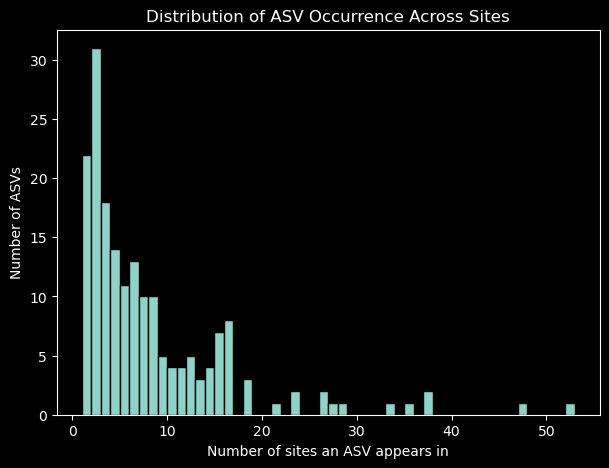

In [ ]:
## plotting distribution of ASVs across sites
# Separate metadata and ASV abundance columns
meta_cols = ["UniqueID", "Site", "Project"]  # adjust names as needed
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# Convert relative abundance to presence/absence
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# Count in how many sites each ASV occurs
asv_site_counts = presence.groupby(all_pollen_clean["Site"]).sum().astype(bool).sum(axis=0)

# Plot
plt.figure(figsize=(7,5))
plt.hist(asv_site_counts, bins=range(1, asv_site_counts.max()+2), edgecolor='black')
plt.xlabel("Number of sites an ASV appears in")
plt.ylabel("Number of ASVs")
plt.title("Distribution of ASV Occurrence Across Sites")
plt.show()

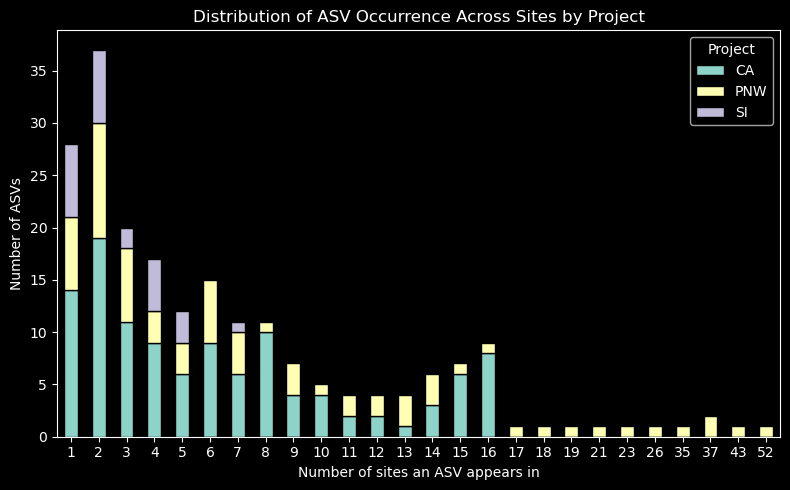

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Separate metadata and ASV columns ---
meta_cols = ["UniqueID", "Site", "Project"]
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# --- 2. Convert relative abundance to presence/absence ---
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# --- 3. Add metadata back ---
presence[meta_cols] = all_pollen_clean[meta_cols]

# --- 4. Count in how many sites each ASV occurs per Project ---
# Melt to long format
presence_long = presence.melt(id_vars=meta_cols, value_vars=asv_cols,
                              var_name="ASV", value_name="Presence")

# Keep only present (1) entries
presence_long = presence_long[presence_long["Presence"] == 1]

# Count in how many **sites** each ASV appears, grouped by Project
asv_site_counts = presence_long.groupby(["Project", "ASV"])["Site"].nunique().reset_index()
asv_site_counts.rename(columns={"Site": "NumSites"}, inplace=True)

# --- 5. Create a histogram table (ASVs vs number of sites, stacked by Project) ---
hist_table = asv_site_counts.groupby(["NumSites", "Project"]).size().unstack(fill_value=0)

# --- 6. Plot stacked bar chart ---
hist_table.plot(kind="bar", stacked=True, figsize=(8,5), edgecolor='black')

plt.xlabel("Number of sites an ASV appears in")
plt.ylabel("Number of ASVs")
plt.title("Distribution of ASV Occurrence Across Sites by Project")
plt.xticks(rotation=0)
plt.legend(title="Project")
plt.tight_layout()
plt.show()


In [ ]:
!pip install matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=598d18b2d6ab3038a816b7ca59f4f63ef7fbf07d4f9a68602fd7f78e0060acfc
  Stored in directory: c:\users\rah10\appdata\local\pip\cache\wheels\86\29\d8\0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn


In [3]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# --- 1. Get unique ASVs per project ---
projects = presence_long["Project"].unique()

# Make sure there are exactly 3 projects
if len(projects) != 3:
    raise ValueError("There must be exactly 3 projects for a 3-set Venn diagram")

set1 = set(presence_long.loc[presence_long["Project"] == projects[0], "ASV"])
set2 = set(presence_long.loc[presence_long["Project"] == projects[1], "ASV"])
set3 = set(presence_long.loc[presence_long["Project"] == projects[2], "ASV"])

# --- 2. Plot the Venn diagram ---
plt.figure(figsize=(6,6))
venn3([set1, set2, set3], set_labels=projects)
plt.title("Overlap of ASVs Across Projects")
plt.show()


NameError: name 'presence_long' is not defined